# 심화 세션 4차 - 딥러닝 ② FOCUS ON TRANSFORMER 사전 예습과제

## 1. RNN의 한계 & Attention 등장

### RNN이 왜 문제였냐면

RNN은 이전 hidden state를 다음으로 넘기면서 시퀀스를 순서대로 처리하는 구조인데, 문제가 좀 있었음.

**① 장기 의존성 문제** — 시퀀스가 길어지면 앞쪽 정보가 hidden state에 제대로 안 남음. 귓속말 여러 명 거치면 내용 바뀌는 거랑 비슷한 느낌.

**② Vanishing Gradient** — 역전파 시 같은 행렬이 계속 곱해지면서 gradient가 앞쪽으로 갈수록 소실됨. 앞쪽 레이어가 사실상 학습이 안 됨.

**③ 병렬화 불가** — $h_t$ 계산하려면 $h_{t-1}$이 반드시 있어야 해서 순서대로밖에 처리 못함. GPU 병렬 연산 활용이 거의 안 됨.

**④ 고정 크기 context vector** — Seq2Seq에서 인코더가 전체 입력을 벡터 하나에 압축해야 하는데, 입력이 길면 정보 다 못 담음.

> LSTM이 ①②를 어느 정도 해결했지만 근본적인 한계는 남아있었음.

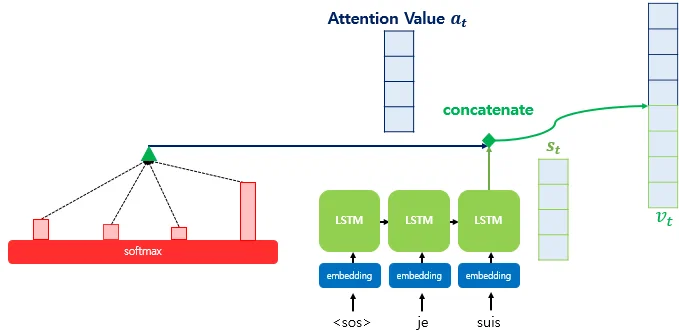

### Attention 등장 배경

Bahdanau (2014) 논문에서 처음 제안. 아이디어 자체는 심플함.

> 디코더가 출력할 때마다, 인코더 출력 전체 중에서 **지금 필요한 부분에만 집중**하면 어떨까?

기존엔 인코더 마지막 hidden state 하나만 디코더로 넘겼는데, Attention 쓰면 인코더의 **모든** hidden state를 참조할 수 있고, 관련 있는 거에 가중치를 더 줌.

```
디코더 현재 상태
    ↓
각 인코더 hidden state와 유사도 계산
    ↓
softmax → attention weight
    ↓
가중합 → context vector → 다음 토큰 예측에 사용
```

장점: 장거리 의존성 해결, 정보 병목 해소, attention weight 시각화로 해석 가능.

### Attention is All You Need (2017)

Bahdanau Attention은 여전히 RNN 위에 얹는 구조였음. Vaswani 등(2017)이 아예 **RNN을 없애고 Attention만으로** 다 해결하는 Transformer를 제안. 이게 현재 BERT, GPT 등 거의 모든 LLM의 기반.


## 2. Self-Attention

### Query, Key, Value 개념

Self-Attention은 같은 시퀀스 내에서 각 토큰이 다른 토큰들과의 관계를 계산하는 것.

도서관 검색에 비유하면:
- **Query**: 내가 찾는 검색어
- **Key**: 각 책의 색인/요약
- **Value**: 실제 책 내용

셋 다 같은 입력 $X$에서 만들어지는데, 각각 다른 가중치 행렬을 곱해서 만듦:

$$Q = XW^Q, \quad K = XW^K, \quad V = XW^V$$

### Cross-Attention vs Self-Attention

**Self-Attention**: Q, K, V 모두 같은 시퀀스에서. 시퀀스 내부 관계 파악. Encoder 전체 + Decoder 1번째 Attention에서 씀.

**Cross-Attention**: Q는 Decoder에서, K와 V는 Encoder 출력에서. 두 시퀀스 사이 관계 파악. Decoder 2번째 Attention에서 씀.

| | Q | K | V | 위치 |
|---|---|---|---|---|
| Self-Attention | 자기 자신 | 자기 자신 | 자기 자신 | Encoder, Decoder 1번째 |
| Cross-Attention | Decoder | Encoder | Encoder | Decoder 2번째 |

---

### Scaled Dot-Product Attention

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

단계별로 보면:

1. **Score** = $QK^T$ → 모든 토큰 쌍의 유사도 계산 `[seq_len, seq_len]`
2. **÷ $\sqrt{d_k}$** → 차원이 커질수록 내적값도 커져서 softmax가 극단으로 쏠리는 걸 방지
3. **softmax** → 각 행의 합이 1이 되도록 정규화 (attention weight)
4. **× V** → attention weight로 Value를 가중합 → 최종 output

결과적으로 각 토큰이 전체 문맥을 반영한 표현을 갖게 됨.

## 3. Multi-Head Attention

### 개념

Attention 하나만 쓰면 하나의 관점에서만 관계를 봄. 근데 언어엔 문법적 관계, 의미적 관계, 지시 관계 등 여러 종류가 동시에 존재함.

→ Attention을 **h개 병렬로** 돌려서 다양한 관점에서 동시에 보자는 게 Multi-Head Attention.

각 Head는 독립적인 $W^Q, W^K, W^V$를 가져서 서로 다른 관계를 학습함.

### 작동 방식

$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h) \cdot W^O$$

$$\text{head}_i = \text{Attention}(QW_i^Q,\ KW_i^K,\ VW_i^V)$$

```
Q, K, V
  ├── Head 1 → Attention → output (seq_len × d_k)
  ├── Head 2 → Attention → output
  └── Head h → Attention → output
                  ↓
              Concat → × W^O → 최종 output (seq_len × d_model)
```

**차원 예시** (논문 base 기준): $d_{model}=512$, $h=8$이면 각 Head는 $d_k=64$ 차원으로 처리하고 합쳐서 다시 512로.

## 4. Transformer 전체 아키텍처

### 전처리 단계

```
텍스트
  ↓ 토큰화
Token ID 시퀀스
  ↓ 임베딩
실수 벡터 (d_model 차원)
  ↓ + Positional Encoding
Transformer 입력
```

**① 토큰화**: 텍스트를 정수 ID로 변환. 단어 단위 쓰면 OOV 문제 있어서 Subword 방식을 씀.
- BPE (GPT 계열), WordPiece (BERT 계열), SentencePiece (다국어 모델)

**② 임베딩**: 각 Token ID를 $d_{model}$ 차원 벡터로 변환. 임베딩 행렬 크기는 `vocab_size × d_model`. 학습 가능한 파라미터.

**③ Positional Encoding**: Self-Attention은 순서를 모름. "나는 사과를"이랑 "사과를 나는"을 구분 못함. 그래서 위치 정보를 임베딩에 더해줌.

$$PE_{(pos, 2i)} = \sin\!\left(\frac{pos}{10000^{2i/d_{model}}}\right), \quad PE_{(pos, 2i+1)} = \cos\!\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

sin/cos 함수 기반이라 학습 파라미터 없고, 훈련에서 안 본 긴 시퀀스에도 쓸 수 있음.

최종 입력 = Token Embedding + Positional Encoding

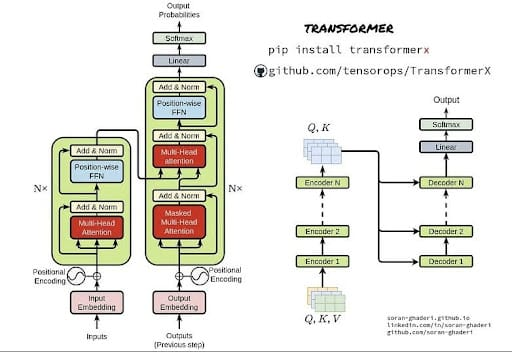

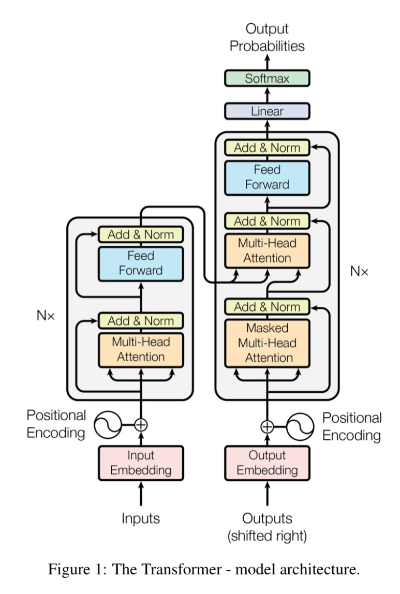

### Encoder

입력 시퀀스를 문맥이 반영된 표현으로 변환하는 역할. N=6개 레이어 쌓음.

각 레이어:
```
입력
  → Multi-Head Self-Attention → Add & LayerNorm
  → Feed-Forward Network (FFN) → Add & LayerNorm
  → 출력
```

**FFN**: $\text{FFN}(x) = \max(0, xW_1+b_1)W_2+b_2$ — 두 선형 변환 + ReLU. 각 토큰에 독립적으로 적용.

**Residual Connection**: 각 서브레이어 출력에 입력을 더해줌 ($x + \text{Sublayer}(x)$). gradient 흐름 안정화.

**LayerNorm**: 활성화 값 정규화. 학습 안정성.

---

### Decoder

Encoder 출력을 참조하면서 출력 토큰을 하나씩 생성하는 역할. N=6개 레이어.

각 레이어:
```
입력 (지금까지 생성한 토큰들)
  → Masked Multi-Head Self-Attention → Add & LayerNorm
  → Multi-Head Cross-Attention (K, V는 Encoder 출력) → Add & LayerNorm
  → FFN → Add & LayerNorm
  → 출력
```

**Masked Self-Attention**: 현재 위치 이후 토큰은 못 보게 마스킹. 미래를 보고 예측하면 치팅이니까. 미래 위치에 $-\infty$를 더하면 softmax 후 0이 됨.

**Cross-Attention**: Q는 Decoder에서, K/V는 Encoder 출력. 번역 시 현재 생성 맥락에서 입력의 어느 부분을 참조할지 결정.

**최종 출력**: Decoder 출력 → Linear ($d_{model}$ → vocab_size) → Softmax → 확률 

### Encoder vs Decoder 정리

| | Encoder | Decoder |
|---|---|---|
| Self-Attention | 양방향 (전체 참조) | 단방향 (과거만) |
| Cross-Attention | 없음 | 있음 |
| 역할 | 입력 이해 | 출력 생성 |
| 대표 모델 | BERT | GPT |


## 메모

- Q, K, V가 같은 입력에서 나오는데 왜 다른지 → 각각 별도 가중치 행렬 곱해서 다른 표현 공간으로 투영되기 때문
- Masked Attention에서 -inf 쓰는 이유 → exp(-inf) = 0이라서 softmax 후 해당 위치 가중치가 0됨
- 요즘은 sin/cos PE 대신 RoPE 같은 걸 많이 씀 (LLaMA 등)

**참고**
> - Vaswani et al. (2017). *Attention Is All You Need.*
> - Jay Alammar, *The Illustrated Transformer* — https://jalammar.github.io/illustrated-transformer/


### 감사합니다 ~~ 🦭🦭